# Sentiment Analysis on IMDB Movie Reviews

# **Install required libraries**

In [1]:
!pip install -q datasets gensim transformers accelerate evaluate

In [2]:
!pip install -U datasets huggingface_hub

# **Import libraries and set random seeds**

In [3]:
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)
print("CUDA available:", torch.cuda.is_available())

Random seed: 42
CUDA available: True


# Loading the IMDB dataset

In [4]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 5.0.1
huggingface_hub: 1.27.0


In [5]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [6]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

# **Creating a validation set**

In [7]:
train_valid = dataset["train"].train_test_split(
    test_size=0.2,
    seed=SEED
)

train_dataset = train_valid["train"]
validation_dataset = train_valid["test"]
test_dataset = dataset["test"]

print("Training:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

Training: 20000
Validation: 5000
Test: 25000


# Converting datasets to Pandas

In [8]:
train_df = pd.DataFrame(train_dataset)
val_df = pd.DataFrame(validation_dataset)
test_df = pd.DataFrame(test_dataset)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(20000, 2)
(5000, 2)
(25000, 2)


In [9]:
train_df.head()

,text,label
0,Stage adaptations often have a major fault. Th...,1
1,'The Rookie' was a wonderful movie about the s...,1
2,"OK,but does that make this a good movie?well,n...",0
3,"Two years ago I watched ""The Matador"" in cinem...",1
4,"Well, I'll be honest: It is not exactly a Shol...",1


# **Checking class balance**

In [10]:
print("Training distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Training distribution:
label
0    10006
1     9994
Name: count, dtype: int64

Validation distribution:
label
1    2506
0    2494
Name: count, dtype: int64

Test distribution:
label
0    12500
1    12500
Name: count, dtype: int64


In [11]:
print(
    train_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

label
0    50.03
1    49.97
Name: proportion, dtype: float64


# **Creating preprocessing function**

In [12]:
import re
import string

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    tokens = text.split()

    return tokens

In [13]:
sample_text = train_df.loc[0, "text"]

print("Original:")
print(sample_text[:500])

print("\nProcessed:")
print(preprocess_text(sample_text)[:50])

Original:
Stage adaptations often have a major fault. They often come out looking like a film camera was simply placed on the stage (Such as "Night Mother"). Sidney Lumet's direction keeps the film alive, which is especially difficult since the picture offered him no real challenge. Still, it's nice to look at for what it is. The chemistry between Michael Caine and Christopher Reeve is quite brilliant. The dynamics of their relationship are surprising. Caine is fantastic as always, and Reeve gets one of h

Processed:
['stage', 'adaptations', 'often', 'have', 'a', 'major', 'fault', 'they', 'often', 'come', 'out', 'looking', 'like', 'a', 'film', 'camera', 'was', 'simply', 'placed', 'on', 'the', 'stage', 'such', 'as', 'night', 'mother', 'sidney', 'lumets', 'direction', 'keeps', 'the', 'film', 'alive', 'which', 'is', 'especially', 'difficult', 'since', 'the', 'picture', 'offered', 'him', 'no', 'real', 'challenge', 'still', 'its', 'nice', 'to', 'look']


# Preprocess TF-IDF datasets

In [14]:
train_df["tokens"] = train_df["text"].apply(preprocess_text)
val_df["tokens"] = val_df["text"].apply(preprocess_text)
test_df["tokens"] = test_df["text"].apply(preprocess_text)

In [15]:
train_df[["text", "tokens"]].head()

,text,tokens
0,Stage adaptations often have a major fault. Th...,"[stage, adaptations, often, have, a, major, fa..."
1,'The Rookie' was a wonderful movie about the s...,"[the, rookie, was, a, wonderful, movie, about,..."
2,"OK,but does that make this a good movie?well,n...","[okbut, does, that, make, this, a, good, movie..."
3,"Two years ago I watched ""The Matador"" in cinem...","[two, years, ago, i, watched, the, matador, in..."
4,"Well, I'll be honest: It is not exactly a Shol...","[well, ill, be, honest, it, is, not, exactly, ..."


# Creating text strings for TF-IDF

In [16]:
train_df["processed_text"] = train_df["tokens"].apply(
    lambda x: " ".join(x)
)

val_df["processed_text"] = val_df["tokens"].apply(
    lambda x: " ".join(x)
)

test_df["processed_text"] = test_df["tokens"].apply(
    lambda x: " ".join(x)
)

In [17]:
train_df[["text", "processed_text"]].head()

,text,processed_text
0,Stage adaptations often have a major fault. Th...,stage adaptations often have a major fault the...
1,'The Rookie' was a wonderful movie about the s...,the rookie was a wonderful movie about the sec...
2,"OK,but does that make this a good movie?well,n...",okbut does that make this a good moviewellnot ...
3,"Two years ago I watched ""The Matador"" in cinem...",two years ago i watched the matador in cinema ...
4,"Well, I'll be honest: It is not exactly a Shol...",well ill be honest it is not exactly a sholay ...


# **Building TF-IDF Model**

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [19]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit TF-IDF ONLY on training data


In [22]:
X_train_tfidf = tfidf.fit_transform(
    train_df["processed_text"]
)

X_val_tfidf = tfidf.transform(
    val_df["processed_text"]
)

X_test_tfidf = tfidf.transform(
    test_df["processed_text"]
)

# Preparing labels

In [23]:
y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

In [24]:
print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)

Train: (20000, 30000)
Validation: (5000, 30000)
Test: (25000, 30000)


# Training Logistic Regression

In [25]:
tfidf_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

tfidf_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
tfidf_val_pred = tfidf_model.predict(X_val_tfidf)

In [27]:
tfidf_test_pred = tfidf_model.predict(X_test_tfidf)

Evaluating TF-IDF Model

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

**Evaluation function**

In [29]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [30]:
tfidf_results = evaluate_model(
    y_test,
    tfidf_test_pred,
    "TF-IDF + Logistic Regression"
)


TF-IDF + Logistic Regression
----------------------------------------
Accuracy : 0.8973
Precision: 0.8929
Recall   : 0.9030
F1-score : 0.8979


## Building Word2Vec Model

# Install/import Gensim

In [31]:
!pip install -q gensim

In [32]:
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression

# Checking tokenized data

In [33]:
train_df["tokens"]
val_df["tokens"]
test_df["tokens"]

,tokens
0,"[i, love, scifi, and, am, willing, to, put, up..."
1,"[worth, the, entertainment, value, of, a, rent..."
2,"[its, a, totally, average, film, with, a, few,..."
3,"[star, rating, saturday, night, friday, night,..."
4,"[first, off, let, me, say, if, you, havent, en..."
...,...
24995,"[just, got, around, to, seeing, monster, man, ..."
24996,"[i, got, this, as, part, of, a, competition, p..."
24997,"[i, got, monster, man, in, a, box, set, of, th..."
24998,"[five, minutes, in, i, started, to, feel, how,..."


In [34]:
train_df["tokens"].head()

,tokens
0,"[stage, adaptations, often, have, a, major, fa..."
1,"[the, rookie, was, a, wonderful, movie, about,..."
2,"[okbut, does, that, make, this, a, good, movie..."
3,"[two, years, ago, i, watched, the, matador, in..."
4,"[well, ill, be, honest, it, is, not, exactly, ..."


# Training Word2Vec Model

In [35]:
word2vec_model = Word2Vec(
    sentences=train_df["tokens"].tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=SEED,
    epochs=10
)

# Checking the vocabulary

In [36]:
print("Vocabulary size:", len(word2vec_model.wv))

Vocabulary size: 48456


In [37]:
word2vec_model.wv["excellent"]

array([-0.37772024, -0.09700535, -0.29347926,  0.30369988, -0.38494962,
        0.2401902 , -0.3485424 , -0.14283596, -0.26887986, -0.00216175,
       -0.14454448,  0.46233395,  0.5547957 ,  0.2909102 , -0.2742478 ,
       -0.30863696,  0.10721616, -0.12631224,  0.19505839,  0.09440555,
        0.06526943,  0.1621638 ,  0.20398675, -0.03445128,  0.05949412,
       -0.14912285, -0.50527304,  0.4291246 , -0.67403835,  0.2608971 ,
       -0.51203144, -0.14907342,  0.30508766, -0.26423886, -0.40762272,
       -0.31919387,  0.11048976,  0.1576718 , -0.12661198,  0.09690149,
       -0.14818156, -0.1308734 ,  0.18520997, -0.22256888,  0.34088844,
       -0.21802647,  0.410807  ,  0.5333073 ,  0.02465933,  0.21171916,
       -0.5755706 , -0.5558807 , -0.38874257,  0.07508377, -0.42145294,
       -0.30636683, -0.10632955,  0.02056799, -0.41123685,  0.27703482,
        0.12812933, -0.0364157 , -0.28633878, -0.16208221,  0.5423062 ,
        0.09532955,  0.19372089, -0.20574686,  0.12026273, -0.39

# Checking the similar words

In [38]:
word2vec_model.wv.most_similar("excellent", topn=10)

[('outstanding', 0.8554738163948059),
 ('fantastic', 0.8191165328025818),
 ('superb', 0.7815665006637573),
 ('terrific', 0.7685132026672363),
 ('amazing', 0.758268415927887),
 ('wonderful', 0.7559547424316406),
 ('great', 0.7511951923370361),
 ('brilliant', 0.7448611855506897),
 ('marvellous', 0.7437659502029419),
 ('fine', 0.7312960624694824)]

In [39]:
word2vec_model.wv.most_similar("terrible", topn=10)

[('horrible', 0.8730530142784119),
 ('awful', 0.8569162487983704),
 ('dreadful', 0.8219327330589294),
 ('bad', 0.7985725402832031),
 ('horrendous', 0.7853848934173584),
 ('substandard', 0.7688488364219666),
 ('horrid', 0.7682754397392273),
 ('atrocious', 0.7574687004089355),
 ('abysmal', 0.7539749145507812),
 ('cheezy', 0.7436842918395996)]

# converting a review into ONE vector

In [40]:
def review_to_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

# Testing the function

In [41]:
sample_vector = review_to_vector(
    train_df["tokens"].iloc[0],
    word2vec_model
)

print("Vector shape:", sample_vector.shape)

Vector shape: (100,)


# Converting all training reviews

In [42]:
X_train_w2v = np.array([
    review_to_vector(tokens, word2vec_model)
    for tokens in train_df["tokens"]
])

In [43]:
print(X_train_w2v.shape)

(20000, 100)


# Converting validation reviews

In [44]:
X_val_w2v = np.array([
    review_to_vector(tokens, word2vec_model)
    for tokens in val_df["tokens"]
])

In [45]:
print(X_val_w2v.shape)

(5000, 100)


# Converting test reviews

In [46]:
X_test_w2v = np.array([
    review_to_vector(tokens, word2vec_model)
    for tokens in test_df["tokens"]
])

In [47]:
print(X_test_w2v.shape)

(25000, 100)


# Training Logistic Regression

In [48]:
w2v_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

w2v_model.fit(
    X_train_w2v,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

# Validation prediction

In [49]:
w2v_val_pred = w2v_model.predict(X_val_w2v)

In [50]:
w2v_val_results = evaluate_model(
    y_val,
    w2v_val_pred,
    "Word2Vec + Logistic Regression - Validation"
)


Word2Vec + Logistic Regression - Validation
----------------------------------------
Accuracy : 0.8676
Precision: 0.8706
Recall   : 0.8643
F1-score : 0.8674


# Final test prediction

In [51]:
w2v_test_pred = w2v_model.predict(X_test_w2v)

In [52]:
w2v_results = evaluate_model(
    y_test,
    w2v_test_pred,
    "Word2Vec + Logistic Regression - Test"
)


Word2Vec + Logistic Regression - Test
----------------------------------------
Accuracy : 0.8551
Precision: 0.8621
Recall   : 0.8454
F1-score : 0.8537


# TF-IDF and Word2Vec - comparison

In [54]:
tfidf_results

{'Model': 'TF-IDF + Logistic Regression',
 'Accuracy': 0.89732,
 'Precision': 0.8928882208686022,
 'Recall': 0.90296,
 'F1-score': 0.8978958673083808}

In [53]:
w2v_results

{'Model': 'Word2Vec + Logistic Regression - Test',
 'Accuracy': 0.85508,
 'Precision': 0.8620605269597846,
 'Recall': 0.84544,
 'F1-score': 0.8536693727533422}

In [55]:
results_df = pd.DataFrame([
    tfidf_results,
    w2v_results
])

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.89732,0.892888,0.90296,0.897896
1,Word2Vec + Logistic Regression - Test,0.85508,0.862061,0.84544,0.853669


# confusion matrix

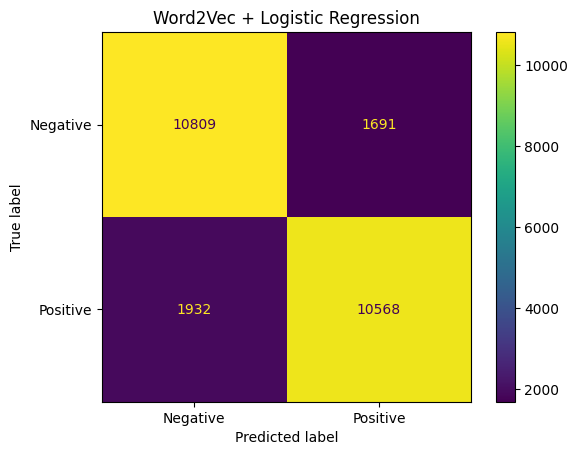

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, w2v_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Word2Vec + Logistic Regression")
plt.show()

In [62]:
word2vec_model #checking

# Building BERT Model

# Install BERT libraries



In [63]:
!pip install -q transformers accelerate

# Import BERT libraries

In [64]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [65]:
import re

def bert_preprocess(text):
    # Remove HTML tags only
    text = re.sub(r"<.*?>", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [66]:
print(train_df["text"].iloc[0][:500])
print("\n--- BERT version ---\n")
print(bert_preprocess(train_df["text"].iloc[0])[:500])

Stage adaptations often have a major fault. They often come out looking like a film camera was simply placed on the stage (Such as "Night Mother"). Sidney Lumet's direction keeps the film alive, which is especially difficult since the picture offered him no real challenge. Still, it's nice to look at for what it is. The chemistry between Michael Caine and Christopher Reeve is quite brilliant. The dynamics of their relationship are surprising. Caine is fantastic as always, and Reeve gets one of h

--- BERT version ---

Stage adaptations often have a major fault. They often come out looking like a film camera was simply placed on the stage (Such as "Night Mother"). Sidney Lumet's direction keeps the film alive, which is especially difficult since the picture offered him no real challenge. Still, it's nice to look at for what it is. The chemistry between Michael Caine and Christopher Reeve is quite brilliant. The dynamics of their relationship are surprising. Caine is fantastic as always,

# Creating BERT text columns

In [67]:
train_df["bert_text"] = train_df["text"].apply(bert_preprocess)
val_df["bert_text"] = val_df["text"].apply(bert_preprocess)
test_df["bert_text"] = test_df["text"].apply(bert_preprocess)

In [68]:
train_df[["bert_text", "label"]].head()

,bert_text,label
0,Stage adaptations often have a major fault. Th...,1
1,'The Rookie' was a wonderful movie about the s...,1
2,"OK,but does that make this a good movie?well,n...",0
3,"Two years ago I watched ""The Matador"" in cinem...",1
4,"Well, I'll be honest: It is not exactly a Shol...",1


# Create Hugging Face datasets[new datasets specifically for BERT]

In [69]:
from datasets import Dataset

bert_train = Dataset.from_pandas(
    train_df[["bert_text", "label"]],
    preserve_index=False
)

bert_val = Dataset.from_pandas(
    val_df[["bert_text", "label"]],
    preserve_index=False
)

bert_test = Dataset.from_pandas(
    test_df[["bert_text", "label"]],
    preserve_index=False
)

In [70]:
print(bert_train)
print(bert_val)
print(bert_test)

Dataset({
    features: ['bert_text', 'label'],
    num_rows: 20000
})
Dataset({
    features: ['bert_text', 'label'],
    num_rows: 5000
})
Dataset({
    features: ['bert_text', 'label'],
    num_rows: 25000
})


# Load BERT tokenizer

In [72]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

# Tokenize the reviews

In [73]:
def tokenize_function(examples):
    return tokenizer(
        examples["bert_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

# Now tokenize

In [74]:
tokenized_train = bert_train.map(
    tokenize_function,
    batched=True
)

tokenized_val = bert_val.map(
    tokenize_function,
    batched=True
)

tokenized_test = bert_test.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

# Removing unnecessary columns

In [75]:
tokenized_train = tokenized_train.remove_columns(["bert_text"])
tokenized_val = tokenized_val.remove_columns(["bert_text"])
tokenized_test = tokenized_test.remove_columns(["bert_text"])

In [76]:
print(tokenized_train.column_names)

['label', 'input_ids', 'token_type_ids', 'attention_mask']


# Loading BERT classification model

In [77]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Checking the device

In [78]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


# Defining evaluation metrics

In [79]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [80]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions
    )

    recall = recall_score(
        labels,
        predictions
    )

    f1 = f1_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Configure BERT training

In [81]:
training_args = TrainingArguments(
    output_dir="./bert_imdb_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    seed=SEED
)

# **Create the Trainer**

In [82]:
trainer = Trainer(
    model=bert_model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

Training BERT Model

In [83]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.290180,0.334377,0.898000,0.946333,0.844374,0.892450


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.290180,0.334377,0.898000,0.946333,0.844374,0.892450
2,0.188810,0.345275,0.917600,0.915147,0.920990,0.918059


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=5000, training_loss=0.24820486660003663, metrics={'train_runtime': 2198.3825, 'train_samples_per_second': 18.195, 'train_steps_per_second': 2.274, 'total_flos': 5262221107200000.0, 'train_loss': 0.24820486660003663, 'epoch': 2.0})

# Evaluate on validation data

In [84]:
val_metrics = trainer.evaluate(
    tokenized_val
)

val_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.188810,0.345275,2,0.917600,0.915147,0.920990,0.918059


{'eval_loss': 0.34527456760406494,
 'eval_accuracy': 0.9176,
 'eval_precision': 0.9151467089611419,
 'eval_recall': 0.9209896249002394,
 'eval_f1': 0.9180588703261734}

# Evaluate BERT on the TEST set

In [85]:
test_metrics = trainer.evaluate(
    tokenized_test
)

test_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.188810,0.319916,2,0.922200,0.912208,0.934320,0.923132


{'eval_loss': 0.31991639733314514,
 'eval_accuracy': 0.9222,
 'eval_precision': 0.9122080762321331,
 'eval_recall': 0.93432,
 'eval_f1': 0.9231316444690353}

In [86]:
bert_results = {
    "Model": "BERT",
    "Accuracy": test_metrics["eval_accuracy"],
    "Precision": test_metrics["eval_precision"],
    "Recall": test_metrics["eval_recall"],
    "F1-score": test_metrics["eval_f1"]
}

bert_results

{'Model': 'BERT',
 'Accuracy': 0.9222,
 'Precision': 0.9122080762321331,
 'Recall': 0.93432,
 'F1-score': 0.9231316444690353}

# Generating BERT predictions

In [87]:
predictions = trainer.predict(
    tokenized_test
)

In [88]:
bert_test_pred = np.argmax(
    predictions.predictions,
    axis=-1
)

In [89]:
print(bert_test_pred[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


# Classification report

In [90]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        bert_test_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92     12500
    Positive       0.91      0.93      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



# Confusion matrix

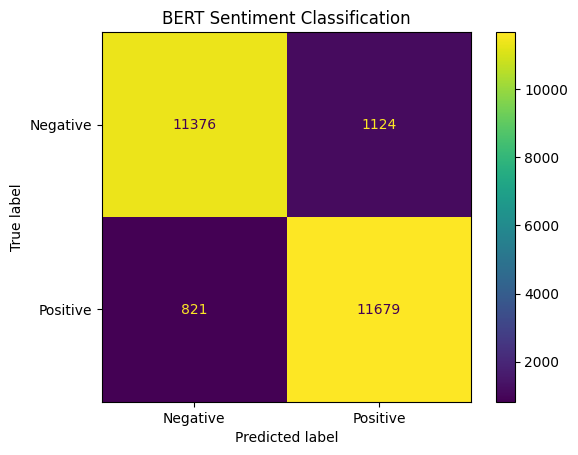

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    bert_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("BERT Sentiment Classification")
plt.show()

#FINAL comparison table

In [92]:
bert_results

{'Model': 'BERT',
 'Accuracy': 0.9222,
 'Precision': 0.9122080762321331,
 'Recall': 0.93432,
 'F1-score': 0.9231316444690353}

In [93]:
final_results = pd.DataFrame([
    tfidf_results,
    w2v_results,
    bert_results
])

final_results

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.89732,0.892888,0.90296,0.897896
1,Word2Vec + Logistic Regression - Test,0.85508,0.862061,0.84544,0.853669
2,BERT,0.92220,0.912208,0.93432,0.923132


# Saving the results

In [94]:
final_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.8973,0.8929,0.9030,0.8979
1,Word2Vec + Logistic Regression - Test,0.8551,0.8621,0.8454,0.8537
2,BERT,0.9222,0.9122,0.9343,0.9231


In [95]:
final_results.sort_values(
    by="F1-score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score
2,BERT,0.92220,0.912208,0.93432,0.923132
0,TF-IDF + Logistic Regression,0.89732,0.892888,0.90296,0.897896
1,Word2Vec + Logistic Regression - Test,0.85508,0.862061,0.84544,0.853669


# Error Rate BERT

In [98]:
error_df = test_df.copy()

error_df["true_label"] = y_test
error_df["predicted_label"] = bert_test_pred

error_df["correct"] = (
    error_df["true_label"] ==
    error_df["predicted_label"]
)

bert_errors = error_df[
    error_df["correct"] == False
].copy()

print("Total test reviews:", len(error_df))
print("BERT errors:", len(bert_errors))
print("BERT correct:", error_df["correct"].sum())

Total test reviews: 25000
BERT errors: 1945
BERT correct: 23055


In [99]:
error_rate = (
    len(bert_errors) /
    len(error_df)
)

print(f"BERT Error Rate: {error_rate:.4%}")

BERT Error Rate: 7.7800%


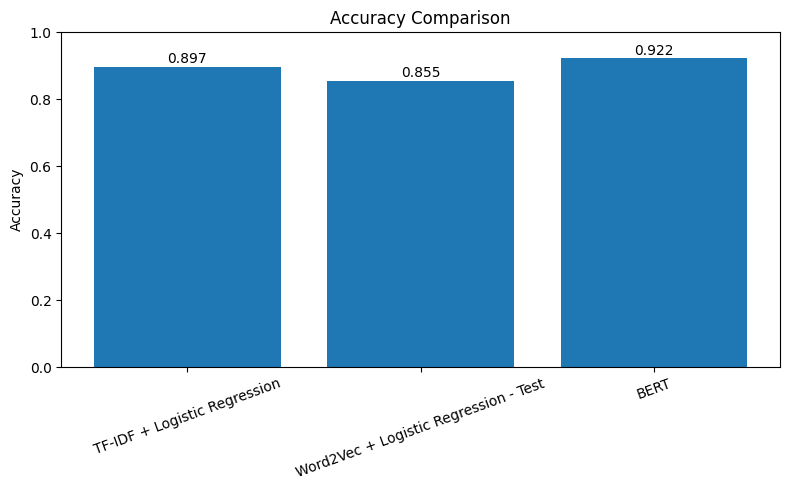

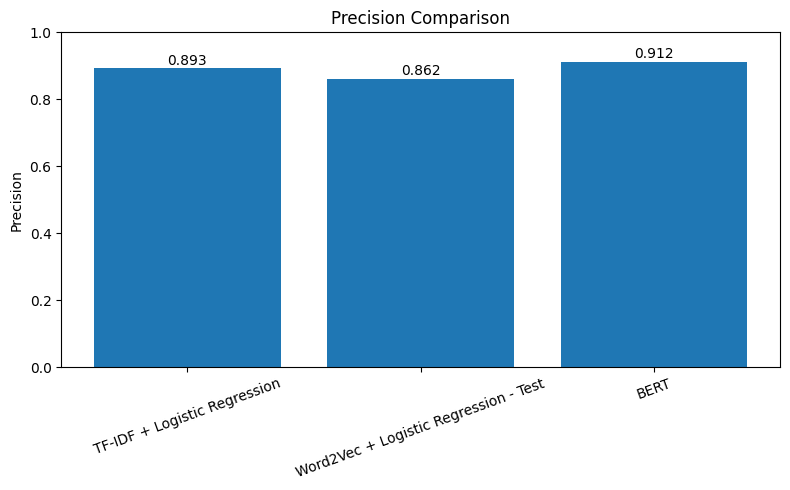

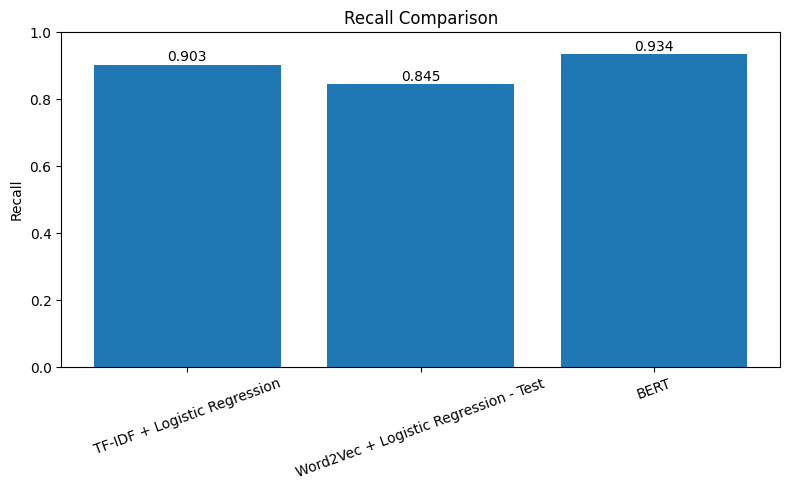

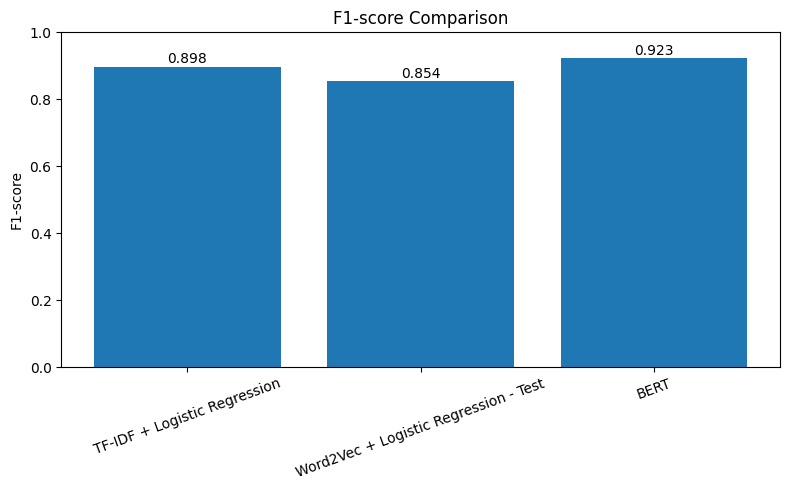

In [96]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

for metric in metrics:
    plt.figure(figsize=(8, 5))

    plt.bar(
        final_results["Model"],
        final_results[metric]
    )

    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=20)

    for i, value in enumerate(final_results[metric]):
        plt.text(
            i,
            value + 0.01,
            f"{value:.3f}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

BERT was the best-performing model for IMDB sentiment classification.

# Displaying some incorrect predictions

In [100]:
for i, row in bert_errors.head(10).iterrows():
    print("=" * 80)

    print("True label:",
          "Positive" if row["true_label"] == 1 else "Negative")

    print("Predicted:",
          "Positive" if row["predicted_label"] == 1 else "Negative")

    print("\nReview:")
    print(row["text"][:1000])

True label: Negative
Predicted: Positive

Review:
First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!
True label: Negative
Predicted: Positive

Review:
Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say she's a somewhat hypocritical

## Quantitative Comparison

In [101]:
best_model = final_results.loc[
    final_results["F1-score"].idxmax()
]

print("Best model based on F1-score:")
print(best_model)

Best model based on F1-score:
Model            BERT
Accuracy       0.9222
Precision    0.912208
Recall        0.93432
F1-score     0.923132
Name: 2, dtype: object


In [102]:
bert_accuracy = bert_results["Accuracy"]
tfidf_accuracy = tfidf_results["Accuracy"]
w2v_accuracy = w2v_results["Accuracy"]

print(
    f"BERT improvement over TF-IDF: "
    f"{(bert_accuracy - tfidf_accuracy) * 100:.2f} percentage points"
)

print(
    f"BERT improvement over Word2Vec: "
    f"{(bert_accuracy - w2v_accuracy) * 100:.2f} percentage points"
)

BERT improvement over TF-IDF: 2.49 percentage points
BERT improvement over Word2Vec: 6.71 percentage points


# **# Conclusion**

This study compared three different text representation approaches for binary sentiment classification on the IMDB movie review dataset: TF-IDF, Word2Vec, and BERT. The models were trained and evaluated using a strict separation of training, validation, and test data to reduce the possibility of data leakage.

Among the three approaches, BERT achieved the best overall performance, obtaining an accuracy of 92.22%, precision of 91.22%, recall of 93.43%, and F1-score of 92.31%. Its superior performance can be attributed to its contextual language representations, which allow it to capture relationships between words and understand sentence context more effectively. This is particularly useful for sentiment expressions involving negation, word order, and complex opinions.

TF-IDF combined with Logistic Regression achieved the second-best results, with 89.73% accuracy and an F1-score of 89.79%. Although it does not capture contextual meaning as effectively as BERT, TF-IDF is computationally efficient, simple to implement, and provides a strong baseline for sentiment classification.

Word2Vec combined with Logistic Regression achieved 85.51% accuracy and an F1-score of 85.37%. The lower performance can partly be explained by representing each review as the average of its word embeddings, which removes word order and some contextual information.

Overall, BERT provided the highest predictive performance, while TF-IDF offered a strong balance between performance and computational efficiency. Word2Vec demonstrated the usefulness of semantic word representations but showed limitations when simple averaging was used for document-level classification. The results demonstrate that contextual representations can substantially improve sentiment classification performance.
